<a href="https://colab.research.google.com/github/jdnogues/DIO/blob/main/Desafio_DIO_Treinamento_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Projeto de Treinamento YOLOv4 com COCO no Google Colab**
**Objetivo:** Configurar o ambiente Darknet, baixar o dataset COCO e iniciar o treinamento de um modelo YOLOv4.

**Passo 1: Verificar e Configurar o Ambiente**

Garantimos que uma GPU está alocada e clonamos a versão mais recomendada do repositório Darknet.

In [1]:
# 1.1 - Verificar se a GPU foi alocada pelo Colab
print("Verificando o status da GPU...")
!nvidia-smi

# 1.2 - Clonar o repositório do Darknet
print("\nClonando o repositório Darknet...")
!git clone https://github.com/AlexeyAB/darknet -q
print("Repositório clonado com sucesso!")

Verificando o status da GPU...
Mon Aug  4 17:27:59 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------

**Passo 2: Compilar o Darknet com Suporte a GPU**

Compilamos o código-fonte do Darknet, habilitando as otimizações para GPU e cuDNN que acelerarão o treinamento.

In [2]:
# 2.1 - Navegar para o diretório do darknet
%cd darknet

# 2.2 - Habilitar GPU, cuDNN e OpenCV no Makefile
print("Habilitando GPU, cuDNN e OpenCV no Makefile...")
!sed -i 's/OPENCV=0/OPENCV=1/' Makefile
!sed -i 's/GPU=0/GPU=1/' Makefile
!sed -i 's/CUDNN=0/CUDNN=1/' Makefile
!sed -i 's/CUDNN_HALF=0/CUDNN_HALF=1/' Makefile
print("Makefile configurado.")

# 2.3 - Compilar o Darknet (pode levar alguns minutos)
print("\nCompilando o Darknet...")
!make
print("Darknet compilado com sucesso!")

/content/darknet
Habilitando GPU, cuDNN e OpenCV no Makefile...
Makefile configurado.

Compilando o Darknet...
mkdir -p ./obj/
mkdir -p backup
mkdir -p results
chmod +x *.sh
g++ -std=c++11 -std=c++11 -Iinclude/ -I3rdparty/stb/include -DOPENCV `pkg-config --cflags opencv4 2> /dev/null || pkg-config --cflags opencv` -DGPU -I/usr/local/cuda/include/ -DCUDNN -DCUDNN_HALF -Wall -Wfatal-errors -Wno-unused-result -Wno-unknown-pragmas -fPIC -rdynamic -Ofast -DOPENCV -DGPU -DCUDNN -I/usr/local/cudnn/include -DCUDNN_HALF -c ./src/image_opencv.cpp -o obj/image_opencv.o
./src/image_opencv.cpp: In function ‘void draw_detections_cv_v3(void**, detection*, int, float, char**, image**, int, int)’:
./src/image_opencv.cpp:945:23: warning: variable ‘rgb’ set but not used []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-but-set-variable-Wunused-but-set-variable]8;;]
  945 |                 float rgb[3];
      |                       ^~~
./src/image_opencv.cpp: In function ‘voi

**Passo 3: Baixar Dados e Pesos Pré-treinados**

Baixamos os pesos convolucionais para transfer learning e executamos o script correto (.sh) para baixar e preparar o dataset COCO 2014.

In [3]:
# Garante que estamos no diretório correto
%cd /content/darknet

# 3.1 - Baixar os pesos convolucionais pré-treinados do YOLOv4
print("Baixando pesos pré-treinados...")
!wget https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov4.conv.137 -q --show-progress

# 3.2 - Baixar o dataset COCO 2014 já formatado para YOLO de um link estável
print("\nBaixando o dataset COCO 2014 pré-formatado (imagens e rótulos)...")
# Este comando baixa as imagens e os rótulos já no formato YOLO
!wget -q --show-progress https://github.com/ultralytics/yolov5/releases/download/v1.0/coco128.zip

# Descompacta o arquivo baixado
print("\nDescompactando o dataset...")
!unzip -q coco128.zip -d coco/

# Remove o arquivo zip para economizar espaço
!rm coco128.zip

print("\nDataset baixado e preparado com sucesso!")

/content/darknet
Baixando pesos pré-treinados...
yolov4.conv.137     100%[===================>] 162.16M  17.9MB/s    in 9.9s    

Baixando o dataset COCO 2014 pré-formatado (imagens e rótulos)...
coco128.zip         100%[===================>]   6.66M  --.-KB/s    in 0.03s   

Descompactando o dataset...

Dataset baixado e preparado com sucesso!


**Passo 4: Configurar os Arquivos de Treinamento**

Este passo é dividido em duas células para garantir a correta criação dos arquivos, evitando erros de sintaxe.

**Célula 4.1: Configurar o arquivo de arquitetura (.cfg)**

(Esta célula ajusta as configurações do modelo)

In [ ]:
# Garante que estamos no diretório correto
%cd /content/darknet

# --- Configurar o arquivo .cfg ---
print("Configurando o arquivo yolov4-coco.cfg...")

# Copia o arquivo de configuração base
!cp cfg/yolov4-custom.cfg cfg/yolov4-coco.cfg

# --- Aplica todas as configurações necessárias ---

# Configurações de batch e subdivisões
!sed -i 's/batch=64/batch=64/' cfg/yolov4-coco.cfg
!sed -i 's/subdivisions=16/subdivisions=32/' cfg/yolov4-coco.cfg

# Ajusta max_batches e steps para 2000
!sed -i 's/max_batches = .*/max_batches = 2000/' cfg/yolov4-coco.cfg
!sed -i 's/steps=.*/steps=1600,1800/' cfg/yolov4-coco.cfg

# Configuração de classes e filtros
!sed -i 's/classes=80/classes=80/' cfg/yolov4-coco.cfg
!sed -i 's/filters=255/filters=255/' cfg/yolov4-coco.cfg

# CORREÇÃO CUDNN: Desativa o redimensionamento aleatório para estabilizar o mAP
# Isso ajuda a prevenir o erro CUDNN_STATUS_BAD_PARAM
!sed -i 's/random=1/random=0/' cfg/yolov4-coco.cfg

print("Arquivo yolov4-coco.cfg atualizado com sucesso!")

**Célula 4.2: Criar o arquivo de dados (.data)**

Instrução Importante: Execute esta célula exatamente como está. O comando %%writefile deve ser a primeira linha para funcionar corretamente e criar o arquivo de texto.

In [5]:
%%writefile data/coco.data
classes = 80
train = /content/darknet/coco/coco128/train.txt
valid = /content/darknet/coco/coco128/train.txt
names = data/coco.names
backup = /content/backup

Writing data/coco.data


**Passo 4.3: Gerar o Arquivo train.txt**
Este código Python irá listar todas as imagens na pasta de treino e salvar os caminhos no arquivo train.txt.

In [6]:
import os

# Garante que estamos no diretório /content/darknet, que será nossa base
%cd /content/darknet

# Define o caminho relativo para a pasta de imagens
image_folder = 'coco/coco128/images/train2017'

# Define o caminho para o arquivo de lista que queremos criar
train_list_path = 'coco/coco128/train.txt'

# Abre o arquivo para escrita
with open(train_list_path, 'w') as f:
    # Obtém o caminho completo para listar os arquivos
    full_image_path = os.path.join(os.getcwd(), image_folder)

    # Lista todos os arquivos na pasta de imagens
    for filename in os.listdir(full_image_path):
        # Garante que estamos processando apenas arquivos de imagem
        if filename.endswith('.jpg'):
            # Escreve o caminho RELATIVO da imagem em uma nova linha
            f.write(os.path.join(image_folder, filename) + '\n')

print(f"Arquivo '{train_list_path}' recriado com sucesso usando caminhos relativos!")

/content/darknet
Arquivo 'coco/coco128/train.txt' recriado com sucesso usando caminhos relativos!


**Passo 5: Iniciar o Treinamento**

Com tudo configurado e corrigido, podemos iniciar o treinamento. O comando agora encontrará todos os arquivos necessários e calculará o mAP periodicamente.

**CASO JÁ TENHA INCIADO UM TREINAMENTO E SALVO OS RESULTADOS, PASSE PARA O PASSO 6**

In [ ]:
# # Inicia o treinamento usando os arquivos configurados e os pesos pré-treinados
# # -dont_show: essencial para não tentar abrir uma janela de GUI no Colab
# # -map: calcula o Mean Average Precision (mAP) no set de validação periodicamente
# # Garante que estamos no diretório correto
# %cd /content/darknet

# # Cria o diretório de backup para salvar os pesos
# # A flag -p garante que o comando não dará erro se a pasta já existir
# !mkdir -p /content/backup
# print("Diretório '/content/backup' criado com sucesso.")

# # Inicia o treinamento
# print("Iniciando o treinamento do YOLOv4...")
# !./darknet detector train data/coco.data cfg/yolov4-coco.cfg yolov4.conv.137 -dont_show -map

**PASSO 6: Restaurar e Continuar um Treinamento Anterior**

Execute este passo ao invés do Passo 5, se você estiver iniciando uma nova sessão no Colab e quiser continuar um treinamento que já havia começado e salvado anteriormente.

**Pré-requisitos:**

Você já deve ter executado os Passos 1, 2 e 4 desta sessão para configurar o ambiente e os arquivos de configuração.

Você tem o arquivo yolo_treinamento_coco.zip salvo no seu computador.

**Célula 6.1: Fazer Upload e Restaurar o Backup**

Este passo fará o upload do seu arquivo .zip e o descompactará, colocando os pesos (.weights) e os arquivos de configuração de volta em seus devidos lugares.

In [7]:
from google.colab import files
import os

# Garante que estamos no diretório /content para receber o upload
%cd /content

# Abre a janela para você selecionar o arquivo 'yolo_treinamento_coco.zip' no seu computador
print("Por favor, selecione o arquivo 'yolo_treinamento_coco.zip' para fazer o upload.")
uploaded = files.upload()

# Pega o nome do arquivo que foi enviado
zip_file_name = list(uploaded.keys())[0]

print(f"\nArquivo '{zip_file_name}' recebido. Descompactando...")

# Descompacta o arquivo. A flag '-d /' garante que a estrutura de pastas
# (/content/backup, /content/darknet/cfg, etc.) seja recriada corretamente.
!unzip -o {zip_file_name} -d /

print("\nBackup restaurado com sucesso! Verificando os pesos na pasta de backup...")

# Verifica se os arquivos de pesos foram restaurados corretamente na pasta de backup
# Você deve ver seus arquivos .weights listados abaixo
!ls -lh /content/backup

/content
Por favor, selecione o arquivo 'yolo_treinamento_coco.zip' para fazer o upload.


Saving yolo_treinamento_coco_it700.zip to yolo_treinamento_coco_it700.zip

Arquivo 'yolo_treinamento_coco_it700.zip' recebido. Descompactando...
Archive:  yolo_treinamento_coco_it700.zip
   creating: /content/backup/
  inflating: /content/backup/yolov4-coco_last.weights  
  inflating: /cfg/yolov4-coco.cfg    
  inflating: /data/coco.data         
  inflating: /chart.png              

Backup restaurado com sucesso! Verificando os pesos na pasta de backup...
total 246M
-rw-r--r-- 1 root root 246M Aug  3 01:34 yolov4-coco_last.weights


**Célula 6.2: Continuar o Treinamento a Partir do Último Ponto Salvo**

Agora que seus pesos foram restaurados na pasta /content/backup, você pode usar o comando abaixo para continuar o treinamento exatamente de onde parou.

In [8]:
# Garante que estamos no diretório correto do darknet
%cd /content/darknet

# O comando é o mesmo do treinamento inicial, mas em vez de 'yolov4.conv.137',
# nós apontamos para o último peso salvo do nosso backup.
# Certifique-se de que o nome do arquivo de peso corresponde ao que você tem na pasta de backup.
print("Continuando o treinamento a partir do último peso salvo...")
!./darknet detector train data/coco.data cfg/yolov4-coco.cfg /content/backup/yolov4-coco_last.weights -dont_show -map

A saída de streaming foi truncada nas últimas 5000 linhas.
v3 (iou loss, Normalizer: (iou: 0.07, obj: 1.00, cls: 1.00) Region 161 Avg (IOU: 0.394029), count: 12, class_loss = 1.745025, iou_loss = 0.590140, total_loss = 2.335166 
 total_bbox = 553473, rewritten_bbox = 1.566111 % 
v3 (iou loss, Normalizer: (iou: 0.07, obj: 1.00, cls: 1.00) Region 139 Avg (IOU: 0.557747), count: 12, class_loss = 4.837099, iou_loss = 62.995300, total_loss = 67.832397 
v3 (iou loss, Normalizer: (iou: 0.07, obj: 1.00, cls: 1.00) Region 150 Avg (IOU: 0.546113), count: 23, class_loss = 8.754025, iou_loss = 20.734089, total_loss = 29.488115 
v3 (iou loss, Normalizer: (iou: 0.07, obj: 1.00, cls: 1.00) Region 161 Avg (IOU: 0.417114), count: 25, class_loss = 8.292356, iou_loss = 2.467324, total_loss = 10.759680 
 total_bbox = 553533, rewritten_bbox = 1.565941 % 


 Tensor Cores are disabled until the first 3000 iterations are reached.
 (next mAP calculation at 1000 iterations) 964/2000: loss=10.1 hours left=3.9
 

**Passo 7: Avaliar e Salvar os Resultados**

Após treinar, os próximos passos são analisar o desempenho e salvar seu trabalho.

**Passo 7.1: Analisar o Gráfico de Treinamento**

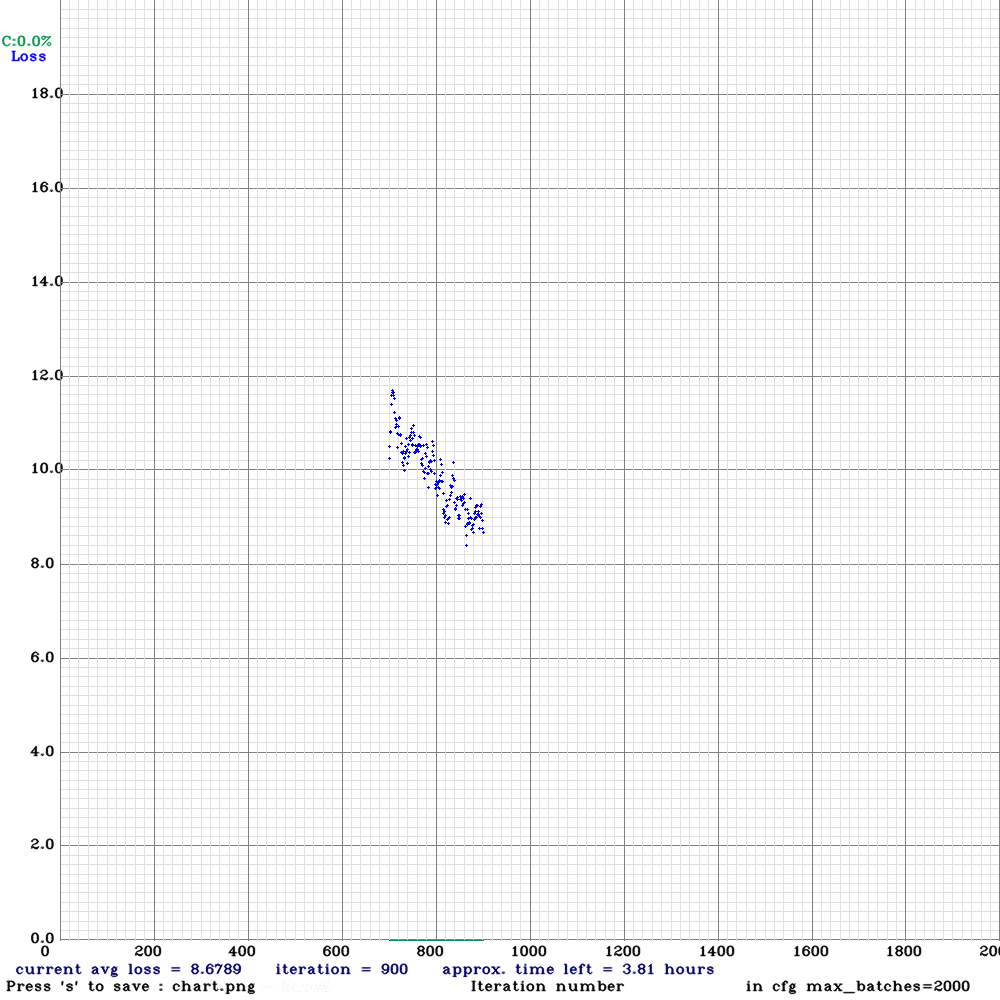

In [9]:
from IPython.display import Image, display

# Exibe o gráfico de treinamento para analisar a convergência do modelo (queda da perda e aumento do mAP)
try:
  display(Image('chart.png'))
except FileNotFoundError:
  print("Arquivo chart.png não encontrado. Execute o treinamento para gerá-lo.")

**Passo 7.2: Testar a Detecção em uma Nova Imagem**

In [13]:
from PIL import Image

# Baixa uma imagem de teste
!wget https://www.caesonline.com/wp-content/uploads/2015/09/Como-fazer-um-cachorro-parar-de-correr-atr%C3%A1s-de-carros.jpg -O test_image.jpeg


# Verifica se o arquivo é uma imagem válida
try:
    img = Image.open('test_image.jpeg')
    print("Imagem de teste baixada e verificada com sucesso!")
except Exception as e:
    print(f"Erro ao verificar a imagem. O arquivo pode estar corrompido. Erro: {e}")

--2025-08-04 18:56:12--  https://www.caesonline.com/wp-content/uploads/2015/09/Como-fazer-um-cachorro-parar-de-correr-atr%C3%A1s-de-carros.jpg
Resolving www.caesonline.com (www.caesonline.com)... 104.21.96.1, 104.21.112.1, 104.21.64.1, ...
Connecting to www.caesonline.com (www.caesonline.com)|104.21.96.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [image/jpeg]
Saving to: ‘test_image.jpeg’

test_image.jpeg         [ <=>                ]  30.99K  --.-KB/s    in 0.001s  

2025-08-04 18:56:12 (22.2 MB/s) - ‘test_image.jpeg’ saved [31729]

Imagem de teste baixada e verificada com sucesso!


/content/darknet
 CUDA-version: 12050 (12040)
, cuDNN: 9.2.1, CUDNN_HALF=1, GPU count: 1  
 CUDNN_HALF=1 
 OpenCV version: 4.5.4
 0 : compute_capability = 750, cudnn_half = 1, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 32, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 1    608 x 608 x   3 ->  608 x 608 x  32 0.639 BF
   1 conv     64       3 x 3/ 2    608 x 608 x  32 ->  304 x 304 x  64 3.407 BF
   2 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   3 route  1 		                           ->  304 x 304 x  64 
   4 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   5 conv     32       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  32 0.379 BF
   6 conv     64       3 x 3/ 1    304 x 304 x  32 ->  304 x 304 x  64 3.407 BF
   7 Shortcut Layer: 4,  wt = 0, wn = 0, outputs: 304 x 304 x  64 0.

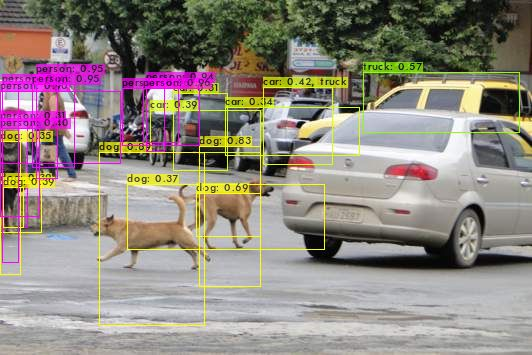

In [14]:
# Garante que estamos no diretório correto
%cd /content/darknet

# Executa a detecção na imagem de teste
# Adicionamos -dont_show para desabilitar a exibição da janela de GUI
!./darknet detector test data/coco.data cfg/yolov4-coco.cfg /content/backup/yolov4-coco_last.weights test_image.jpeg -thresh 0.3 -dont_show

print("\nDetecção concluída! O resultado foi salvo em 'predictions.jpg'.")

img = Image.open('predictions.jpg')
display(img)

**Célula 7.3: Compactar e Baixar os Resultados**

**MUITO IMPORTANTE:** O ambiente do Colab é temporário. Salve seus pesos treinados antes de fechar a janela!

In [15]:
from google.colab import files

print("Compactando os resultados do treinamento para download...")
# Compacta a pasta de backup (com os pesos), o gráfico e os arquivos de configuração
!zip -r /content/yolo_treinamento_coco.zip /content/backup cfg/yolov4-coco.cfg data/coco.data chart.png -q

print("Arquivo 'yolo_treinamento_coco.zip' criado.")
# Inicia o download do arquivo zip para sua máquina local
files.download('/content/yolo_treinamento_coco.zip')

Compactando os resultados do treinamento para download...
Arquivo 'yolo_treinamento_coco.zip' criado.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>